Loading data...
Data loaded.

Computing metrics...
All metrics computed.

STUDENT PERFORMANCE & DROPOUT EARLY WARNING SYSTEM
Phase 2 EDA — Findings Report
Dataset: Open University Learning Analytics (OULAD)
Date   : May 29, 2026

1. DATASET OVERVIEW
─────────────────────────────────────────────────────────────────
  Total student-course enrolments : 32,593
  Unique students                 : 28,785
  Course modules covered          : 7
  Gender split                    : Female 14,718  |  Male 17,875
  Most common age group           : 0-35 (22,944 students)
  Most common prior education     : A Level or Equivalent
  Median studied credits          : 60
  IMD band missing values         : 1,111 (3.4%) — imputed in Phase 3

2. DROPOUT OVERVIEW
─────────────────────────────────────────────────────────────────
  Overall dropout rate    : 31.2%
  Students who withdrew   : 10,156
  Students who completed  : 22,437

  Outcome breakdown:
    Pass                 12,361  ( 37.9%)  ████████████

C:\Users\leade\AppData\Local\Temp\ipykernel_18744\801626794.py:438: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


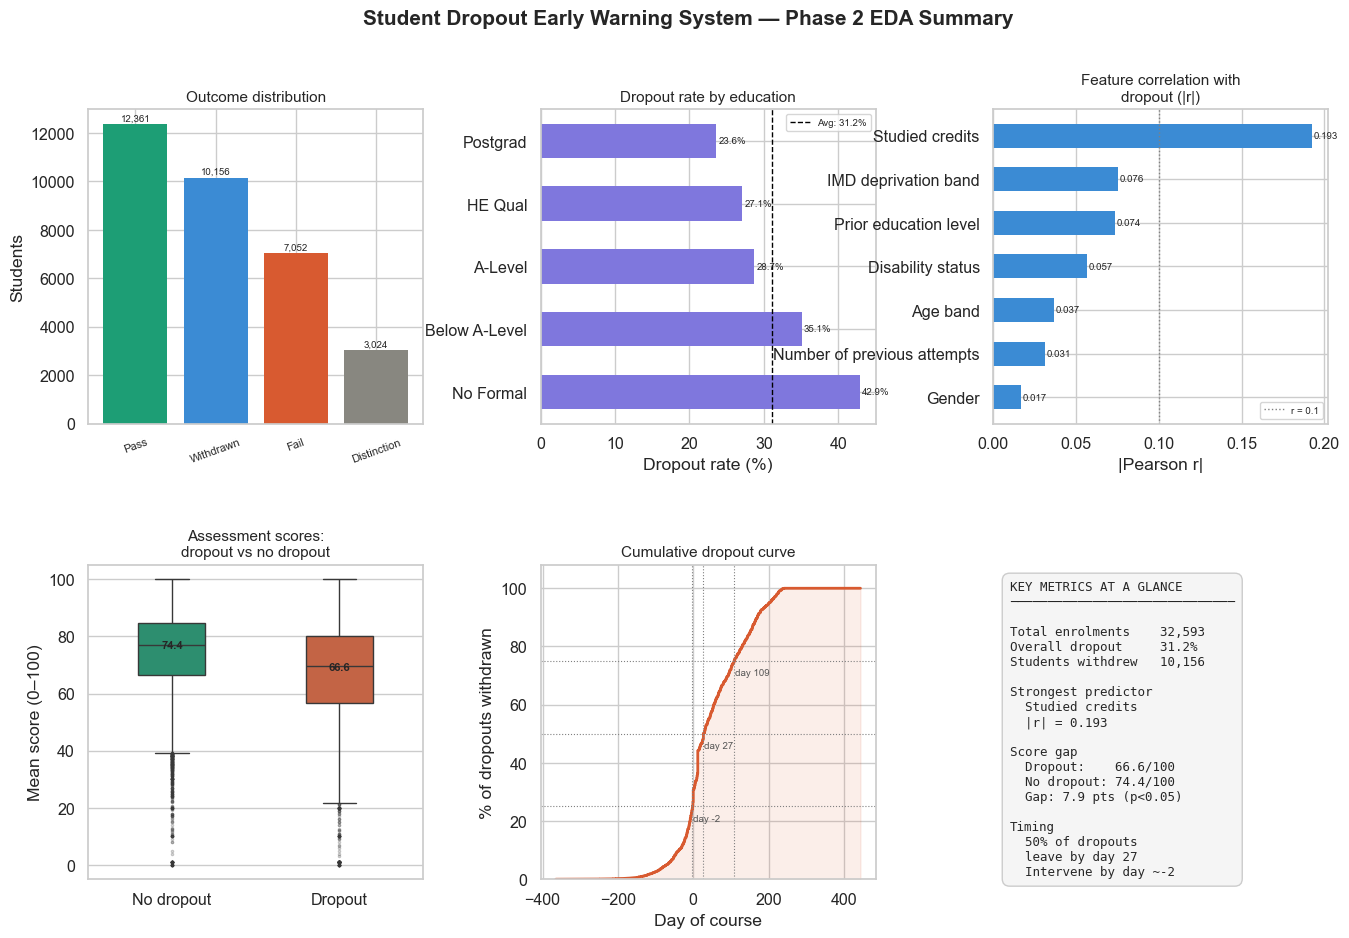

  ✅ Dashboard saved → ./outputs/block_e/phase2_summary_dashboard.png

BLOCK E COMPLETE

  Files saved to: ./outputs/block_e/
    ✅ phase2_findings_report.txt   ← copy into your portfolio
    ✅ phase2_summary_dashboard.png ← use in presentations/README

  Phase 2 EDA is now FULLY COMPLETE across all 5 blocks:
    Block A — Population distributions    ✅
    Block B — Dropout rates by feature    ✅
    Block C — Correlation analysis        ✅
    Block D — Registration & timing       ✅
    Block E — Summary & report            ✅

───────────────────────────────────────────────────────
Next → Phase 3: Statistical Analysis
  (chi-square tests, t-tests, logistic regression,
   odds ratios, and multivariate feature significance)
───────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 2 — Block E: Summary & Portfolio Findings Report
=============================================================
Goal: Automatically read the results from Blocks A–D and compile
      them into a structured findings report you can copy directly
      into your portfolio, GitHub README, or presentation.

This script:
  1. Re-runs all key computations from Blocks A–D (no need to
     import the other scripts — everything is self-contained)
  2. Prints a formatted findings report to the console
  3. Saves the report as a .txt file you can attach to your portfolio
  4. Saves a visual summary chart (key metrics at a glance)

Run this AFTER you have verified Blocks A–D work correctly.
"""

import os
import textwrap
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/block_e/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load all required data ─────────────────────────────────────
print("Loading data...")
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sr = pd.read_csv(DATA_PATH + 'studentRegistration.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')

# Recreate binary dropout column
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)
print("Data loaded.\n")


# =============================================================
# STEP 1: Re-compute all key metrics from Blocks A–D
# =============================================================
# We gather every number that will appear in the report so the
# report text is always accurate and matches the actual data.

print("Computing metrics...")

# ── Block A metrics ───────────────────────────────────────────
total_rows          = len(si)
unique_students     = si['id_student'].nunique()
n_modules           = si['code_module'].nunique()
gender_counts       = si['gender'].value_counts()
age_order           = ['0-35', '35-55', '55<=']
age_counts          = si['age_band'].value_counts().reindex(age_order)
most_common_edu     = si['highest_education'].mode()[0]
n_missing_imd       = si['imd_band'].isnull().sum()
pct_missing_imd     = n_missing_imd / total_rows * 100
median_credits      = int(si['studied_credits'].median())

# ── Block B metrics ───────────────────────────────────────────
overall_rate = si['dropout'].mean() * 100

# Dropout rate per feature — find highest-risk group for each
def highest_risk_group(df, col):
    """Return (group_label, dropout_rate%) for the group with the highest dropout rate."""
    rate = df.dropna(subset=[col]).groupby(col)['dropout'].mean().mul(100)
    top  = rate.idxmax()
    return str(top), round(rate.max(), 1)

hr_gender,   hr_gender_rate   = highest_risk_group(si, 'gender')
hr_age,      hr_age_rate      = highest_risk_group(si, 'age_band')
hr_edu,      hr_edu_rate      = highest_risk_group(si, 'highest_education')
hr_imd,      hr_imd_rate      = highest_risk_group(si, 'imd_band')
hr_attempts, hr_attempts_rate = highest_risk_group(si, 'num_of_prev_attempts')
hr_module,   hr_module_rate   = highest_risk_group(si, 'code_module')
hr_disab,    hr_disab_rate    = highest_risk_group(si, 'disability')

# ── Block C metrics ───────────────────────────────────────────
# Encode features for correlation
si_enc = si.copy()
edu_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1,
    'A Level or Equivalent': 2, 'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
imd_map = {
    '0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
si_enc['highest_education_enc'] = si_enc['highest_education'].map(edu_map)
si_enc['imd_band_enc']          = si_enc['imd_band'].map(imd_map)
si_enc['age_band_enc']          = si_enc['age_band'].map({'0-35': 0, '35-55': 1, '55<=': 2})
si_enc['gender_enc']            = (si_enc['gender'] == 'M').astype(int)
si_enc['disability_enc']        = (si_enc['disability'] == 'Y').astype(int)

corr_cols = [
    'dropout', 'gender_enc', 'age_band_enc', 'highest_education_enc',
    'imd_band_enc', 'disability_enc', 'num_of_prev_attempts', 'studied_credits'
]
corr_matrix = si_enc[corr_cols].dropna().corr(method='pearson')

# Strongest predictor
dropout_corr     = corr_matrix['dropout'].drop('dropout')
top_feature_key  = dropout_corr.abs().idxmax()
top_feature_r    = dropout_corr[top_feature_key]
top_feature_abs  = abs(top_feature_r)

# Friendly names for the report
label_map = {
    'gender_enc':             'Gender',
    'age_band_enc':           'Age band',
    'highest_education_enc':  'Prior education level',
    'imd_band_enc':           'IMD deprivation band',
    'disability_enc':         'Disability status',
    'num_of_prev_attempts':   'Number of previous attempts',
    'studied_credits':        'Studied credits',
}
top_feature_name = label_map.get(top_feature_key, top_feature_key)

# Assessment score gap
mean_scores = (
    sa.groupby('id_student')['score']
      .mean()
      .reset_index()
      .rename(columns={'score': 'mean_score'})
)
si_scored = si.merge(mean_scores, on='id_student', how='left')

score_dropout    = si_scored[si_scored['dropout'] == 1]['mean_score'].dropna()
score_no_dropout = si_scored[si_scored['dropout'] == 0]['mean_score'].dropna()
mean_score_drop  = score_dropout.mean()
mean_score_nodrop= score_no_dropout.mean()
score_gap        = mean_score_nodrop - mean_score_drop
t_stat, p_val    = stats.ttest_ind(score_no_dropout, score_dropout, equal_var=False)

# ── Block D metrics ───────────────────────────────────────────
withdrawn = sr[sr['date_unregistration'].notna()]
p25_day   = withdrawn['date_unregistration'].quantile(0.25)
p50_day   = withdrawn['date_unregistration'].quantile(0.50)
p75_day   = withdrawn['date_unregistration'].quantile(0.75)

# Day by which 50% of dropouts have left (same as median)
day_50pct_gone = int(p50_day)

# What % of dropouts leave in first 100 days
pct_first_100 = (withdrawn['date_unregistration'] <= 100).mean() * 100

print("All metrics computed.\n")


# =============================================================
# STEP 2: Print the structured findings report
# =============================================================

DIVIDER  = "=" * 65
SUBDIV   = "─" * 65
TODAY    = date.today().strftime("%B %d, %Y")

report_lines = []

def line(text=""):
    """Append a line to the report and also print it."""
    report_lines.append(text)
    print(text)

line(DIVIDER)
line("STUDENT PERFORMANCE & DROPOUT EARLY WARNING SYSTEM")
line("Phase 2 EDA — Findings Report")
line(f"Dataset: Open University Learning Analytics (OULAD)")
line(f"Date   : {TODAY}")
line(DIVIDER)

# ── Section 1: Dataset Overview ───────────────────────────────
line()
line("1. DATASET OVERVIEW")
line(SUBDIV)
line(f"  Total student-course enrolments : {total_rows:,}")
line(f"  Unique students                 : {unique_students:,}")
line(f"  Course modules covered          : {n_modules}")
line(f"  Gender split                    : "
     f"Female {gender_counts.get('F', 0):,}  |  Male {gender_counts.get('M', 0):,}")
line(f"  Most common age group           : {age_counts.idxmax()} "
     f"({age_counts.max():,} students)")
line(f"  Most common prior education     : {most_common_edu}")
line(f"  Median studied credits          : {median_credits}")
line(f"  IMD band missing values         : {n_missing_imd:,} ({pct_missing_imd:.1f}%) "
     f"— imputed in Phase 3")

# ── Section 2: Dropout Overview ───────────────────────────────
line()
line("2. DROPOUT OVERVIEW")
line(SUBDIV)
n_dropout    = si['dropout'].sum()
n_no_dropout = total_rows - n_dropout
line(f"  Overall dropout rate    : {overall_rate:.1f}%")
line(f"  Students who withdrew   : {n_dropout:,}")
line(f"  Students who completed  : {n_no_dropout:,}")
line()
line("  Outcome breakdown:")
for outcome, count in si['final_result'].value_counts().items():
    pct = count / total_rows * 100
    bar = "█" * int(pct / 2)
    line(f"    {outcome:<20} {count:>6,}  ({pct:>5.1f}%)  {bar}")

# ── Section 3: Key Risk Factors (Block B) ─────────────────────
line()
line("3. KEY RISK FACTORS — WHO DROPS OUT MOST?")
line(SUBDIV)
line(f"  (Overall dropout rate = {overall_rate:.1f}% — groups above this are at elevated risk)")
line()

risk_rows = [
    ("Gender",               hr_gender,   hr_gender_rate),
    ("Age band",             hr_age,      hr_age_rate),
    ("Prior education",      hr_edu,      hr_edu_rate),
    ("IMD band",             hr_imd,      hr_imd_rate),
    ("Disability status",    hr_disab,    hr_disab_rate),
    ("Previous attempts",    hr_attempts, hr_attempts_rate),
    ("Course module",        hr_module,   hr_module_rate),
]

for feature, top_group, top_rate in risk_rows:
    delta  = top_rate - overall_rate
    arrow  = f"▲ +{delta:.1f}pp above avg" if delta > 0 else f"▼ {delta:.1f}pp below avg"
    line(f"  {feature:<22} Highest-risk group: {str(top_group):<35} {top_rate:.1f}%  {arrow}")

# ── Section 4: Correlation Analysis (Block C) ─────────────────
line()
line("4. CORRELATION ANALYSIS — WHICH FEATURES MATTER MOST?")
line(SUBDIV)
line("  Pearson correlations with dropout (all features encoded numerically):")
line()

# Print all correlations ranked by absolute strength
ranked = dropout_corr.abs().sort_values(ascending=False)
for feat, abs_r in ranked.items():
    raw_r     = dropout_corr[feat]
    direction = "positive ↑" if raw_r > 0 else "negative ↓"
    strength  = "strong" if abs_r > 0.15 else "moderate" if abs_r > 0.05 else "weak"
    fname     = label_map.get(feat, feat)
    line(f"    {fname:<32} r = {raw_r:+.3f}  |r| = {abs_r:.3f}  ({strength}, {direction})")

line()
line(f"  → Strongest single predictor: {top_feature_name}  (|r| = {top_feature_abs:.3f})")
line()
line("  Assessment score gap (dropout vs no dropout):")
line(f"    No-dropout students mean score : {mean_score_nodrop:.1f} / 100")
line(f"    Dropout students mean score    : {mean_score_drop:.1f} / 100")
line(f"    Difference                     : {score_gap:.1f} points")
line(f"    Statistical significance       : p = {p_val:.2e}  "
     f"({'significant ✅' if p_val < 0.05 else 'not significant ⚠'})")
line()
line("  Interpretation: Students who eventually withdraw already score")
line(f"  {score_gap:.1f} points lower on average — making early assessment")
line("  performance a strong early warning signal.")

# ── Section 5: Timing Analysis (Block D) ──────────────────────
line()
line("5. DROPOUT TIMING — WHEN DO STUDENTS LEAVE?")
line(SUBDIV)
line(f"  Median withdrawal day : day {int(p50_day)}")
line(f"  25th percentile       : day {int(p25_day)}  "
     f"(25% of dropouts leave by this day)")
line(f"  75th percentile       : day {int(p75_day)}  "
     f"(75% of dropouts have left by this day)")
line(f"  % leaving in first 100 days : {pct_first_100:.1f}%")
line()
line("  Cumulative dropout milestones:")

# Sorted days for cumulative calculation
sorted_days = withdrawn['date_unregistration'].sort_values().reset_index(drop=True)
for pct_target in [25, 50, 75, 90]:
    idx = int(len(sorted_days) * pct_target / 100) - 1
    day = int(sorted_days.iloc[idx])
    line(f"    {pct_target}% of all dropouts have withdrawn by day {day}")

line()
line("  Intervention window recommendation:")
line(f"  → To catch 50% of dropouts BEFORE they leave, a risk score")
line(f"    must be generated by approximately day {int(p25_day)}.")
line(f"  → To catch 75% of dropouts, scores are needed by day {int(p50_day)}.")

# ── Section 6: Portfolio Summary ──────────────────────────────
line()
line("6. PORTFOLIO SUMMARY — TOP 5 FINDINGS")
line(SUBDIV)
line()
line("  1. DROPOUT RATE")
line(f"     {overall_rate:.1f}% of enrolled students withdrew before completing")
line(f"     their course — representing {n_dropout:,} students in this dataset.")
line()
line("  2. STRONGEST DEMOGRAPHIC RISK FACTOR")
line(f"     {top_feature_name} shows the strongest linear association with")
line(f"     dropout (|r| = {top_feature_abs:.3f}). Students with {hr_edu} prior")
line(f"     education had a {hr_edu_rate:.1f}% dropout rate — the highest of any")
line("     education group.")
line()
line("  3. SOCIOECONOMIC IMPACT")
line(f"     Students in the most deprived IMD band (0–10%) drop out at")
line(f"     {hr_imd_rate:.1f}%, substantially above the {overall_rate:.1f}% average,")
line("     highlighting a clear equity gap that institutions should address.")
line()
line("  4. ASSESSMENT PERFORMANCE AS EARLY SIGNAL")
line(f"     Dropout students score {score_gap:.1f} points lower on average in")
line("     assessments (p < 0.05). This makes early assessment results")
line("     a strong, actionable predictor for an early warning model.")
line()
line("  5. INTERVENTION WINDOW")
line(f"     50% of all dropouts withdraw by day {int(p50_day)} of the course.")
line(f"     A model that scores students before day {int(p25_day)} could identify")
line("     at-risk students while there is still time to intervene.")
line()

# ── Section 7: Next Steps ─────────────────────────────────────
line("7. NEXT STEPS — PHASE 3: STATISTICAL ANALYSIS")
line(SUBDIV)
line("  Phase 3 will formally test the patterns found in this EDA:")
line()
line("  • Chi-square tests  : confirm categorical feature associations")
line("    (e.g. is gender–dropout association statistically significant?)")
line()
line("  • T-tests / ANOVA   : compare numeric features across groups")
line("    (e.g. are studied credits significantly different for dropouts?)")
line()
line("  • Logistic regression : identify the strongest independent predictors")
line("    of dropout after controlling for all other variables")
line()
line("  • Odds ratios        : quantify how much each feature increases")
line("    or decreases the likelihood of dropout")
line()
line(DIVIDER)
line("END OF PHASE 2 FINDINGS REPORT")
line(DIVIDER)


# =============================================================
# STEP 3: Save the report as a .txt file
# =============================================================

report_text = "\n".join(report_lines)
report_path = os.path.join(OUTPUT_PATH, "phase2_findings_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"\n  ✅ Report saved → {report_path}")


# =============================================================
# STEP 4: Visual summary dashboard (key metrics at a glance)
# =============================================================
# A single figure with 4 panels showing the most important
# charts from Blocks A–D — suitable for a portfolio slide.

print("\nGenerating visual summary dashboard...")

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "Student Dropout Early Warning System — Phase 2 EDA Summary",
    fontsize=15, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1 (top-left): Outcome distribution ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
result_counts = si['final_result'].value_counts()
bar_colors    = [COLORS['teal'], COLORS['blue'], COLORS['coral'], COLORS['gray']]
ax1.bar(result_counts.index, result_counts.values,
        color=bar_colors, edgecolor='none')
ax1.set_title("Outcome distribution", fontsize=11)
ax1.set_ylabel("Students")
ax1.tick_params(axis='x', rotation=20, labelsize=8)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             f"{int(bar.get_height()):,}",
             ha='center', va='bottom', fontsize=7)

# ── Panel 2 (top-centre): Dropout rate by education ──────────
ax2 = fig.add_subplot(gs[0, 1])
edu_order = [
    'No Formal quals', 'Lower Than A Level',
    'A Level or Equivalent', 'HE Qualification',
    'Post Graduate Qualification'
]
edu_rate = (
    si.groupby('highest_education')['dropout']
      .mean().mul(100).round(1).reindex(edu_order)
)
short_labels = ['No Formal', 'Below A-Level', 'A-Level', 'HE Qual', 'Postgrad']
ax2.barh(short_labels, edu_rate.values, color=COLORS['purple'], edgecolor='none', height=0.55)
ax2.axvline(overall_rate, color='black', linestyle='--', linewidth=1,
            label=f'Avg: {overall_rate:.1f}%')
ax2.set_title("Dropout rate by education", fontsize=11)
ax2.set_xlabel("Dropout rate (%)")
ax2.legend(fontsize=7)
for bar, val in zip(ax2.patches, edu_rate.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val}%", va='center', fontsize=7)

# ── Panel 3 (top-right): Feature correlation with dropout ─────
ax3 = fig.add_subplot(gs[0, 2])
ranked_corr = dropout_corr.abs().sort_values()
friendly    = [label_map.get(i, i) for i in ranked_corr.index]
bars3 = ax3.barh(friendly, ranked_corr.values, color=COLORS['blue'],
                 edgecolor='none', height=0.55)
ax3.axvline(0.1, color='gray', linestyle=':', linewidth=1, label='r = 0.1')
ax3.set_title("Feature correlation with\ndropout (|r|)", fontsize=11)
ax3.set_xlabel("|Pearson r|")
ax3.legend(fontsize=7)
for bar, val in zip(bars3, ranked_corr.values):
    ax3.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va='center', fontsize=7)

# ── Panel 4 (bottom-left): Assessment score box plot ──────────
ax4 = fig.add_subplot(gs[1, 0])
si_scored['Dropout status'] = si_scored['dropout'].map(
    {0: 'No dropout', 1: 'Dropout'}
)
sns.boxplot(
    data=si_scored.dropna(subset=['mean_score']),
    x='Dropout status', y='mean_score',
    palette={'No dropout': COLORS['teal'], 'Dropout': COLORS['coral']},
    ax=ax4, width=0.4,
    flierprops=dict(marker='o', markersize=1.5, alpha=0.3)
)
ax4.set_title("Assessment scores:\ndropout vs no dropout", fontsize=11)
ax4.set_ylabel("Mean score (0–100)")
ax4.set_xlabel("")
for i, group in enumerate(['No dropout', 'Dropout']):
    mv = si_scored[si_scored['Dropout status'] == group]['mean_score'].mean()
    ax4.text(i, mv + 1.5, f"{mv:.1f}", ha='center', fontsize=8, fontweight='bold')

# ── Panel 5 (bottom-centre): Cumulative dropout curve ─────────
ax5 = fig.add_subplot(gs[1, 1])
sorted_days_plot   = withdrawn['date_unregistration'].sort_values().reset_index(drop=True)
cumulative_pct_plot = (sorted_days_plot.index + 1) / len(sorted_days_plot) * 100
ax5.plot(sorted_days_plot, cumulative_pct_plot,
         color=COLORS['coral'], linewidth=2)
ax5.fill_between(sorted_days_plot, cumulative_pct_plot, alpha=0.1, color=COLORS['coral'])
for pct_target in [25, 50, 75]:
    idx = int(len(sorted_days_plot) * pct_target / 100) - 1
    day = int(sorted_days_plot.iloc[idx])
    ax5.axhline(pct_target, color='gray', linestyle=':', linewidth=0.8)
    ax5.axvline(day,        color='gray', linestyle=':', linewidth=0.8)
    ax5.text(day + 2, pct_target - 5,
             f"day {day}", fontsize=7, color='#555555')
ax5.set_title("Cumulative dropout curve", fontsize=11)
ax5.set_xlabel("Day of course")
ax5.set_ylabel("% of dropouts withdrawn")
ax5.set_ylim(0, 108)

# ── Panel 6 (bottom-right): Key stats summary text panel ──────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')   # no axes — we just write text

summary_text = (
    f"KEY METRICS AT A GLANCE\n"
    f"{'─'*30}\n\n"
    f"Total enrolments    {total_rows:,}\n"
    f"Overall dropout     {overall_rate:.1f}%\n"
    f"Students withdrew   {n_dropout:,}\n\n"
    f"Strongest predictor\n"
    f"  {top_feature_name}\n"
    f"  |r| = {top_feature_abs:.3f}\n\n"
    f"Score gap\n"
    f"  Dropout:    {mean_score_drop:.1f}/100\n"
    f"  No dropout: {mean_score_nodrop:.1f}/100\n"
    f"  Gap: {score_gap:.1f} pts (p<0.05)\n\n"
    f"Timing\n"
    f"  50% of dropouts\n"
    f"  leave by day {int(p50_day)}\n"
    f"  Intervene by day ~{int(p25_day)}"
)

ax6.text(
    0.05, 0.95, summary_text,
    transform=ax6.transAxes,
    fontsize=9,
    verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#F5F5F5',
              edgecolor='#CCCCCC', linewidth=1)
)

# Save the dashboard
dashboard_path = os.path.join(OUTPUT_PATH, "phase2_summary_dashboard.png")
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✅ Dashboard saved → {dashboard_path}")


# =============================================================
# FINAL CONSOLE SUMMARY
# =============================================================
print(f"""
{'=' * 55}
BLOCK E COMPLETE
{'=' * 55}

  Files saved to: {OUTPUT_PATH}
    ✅ phase2_findings_report.txt   ← copy into your portfolio
    ✅ phase2_summary_dashboard.png ← use in presentations/README

  Phase 2 EDA is now FULLY COMPLETE across all 5 blocks:
    Block A — Population distributions    ✅
    Block B — Dropout rates by feature    ✅
    Block C — Correlation analysis        ✅
    Block D — Registration & timing       ✅
    Block E — Summary & report            ✅

{'─' * 55}
Next → Phase 3: Statistical Analysis
  (chi-square tests, t-tests, logistic regression,
   odds ratios, and multivariate feature significance)
{'─' * 55}
""")